In [9]:
import numpy as np
import pandas as pd 


In [10]:
df = pd.read_csv('data.csv')
print(df.head(5))

   user_id    subject preferred_time  revision_time study_time  duration  \
0        1       Math        Evening             60       7 PM        60   
1        1    Physics        Evening             60       7 PM        30   
2        1       Math        Evening             60       7 PM        60   
3        1  Chemistry        Evening             60       7 PM         0   
4        1       Math        Evening             60       7 PM        60   

   studied reminder_response        date  
0        1               Yes  2026-04-01  
1        0                No  2026-04-02  
2        1               Yes  2026-04-03  
3        0                No  2026-04-04  
4        1               Yes  2026-04-05  


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 502 entries, 0 to 501
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   user_id            502 non-null    int64
 1   subject            502 non-null    str  
 2   preferred_time     502 non-null    str  
 3   revision_time      502 non-null    int64
 4   study_time         502 non-null    str  
 5   duration           502 non-null    int64
 6   studied            502 non-null    int64
 7   reminder_response  502 non-null    str  
 8   date               502 non-null    str  
dtypes: int64(4), str(5)
memory usage: 35.4 KB


In [12]:
df.isnull().sum()

user_id              0
subject              0
preferred_time       0
revision_time        0
study_time           0
duration             0
studied              0
reminder_response    0
date                 0
dtype: int64

In [13]:
df['reminder_response']=df['reminder_response'].map({'Yes':1,'No':0})
print(df)

     user_id            subject preferred_time  revision_time study_time  \
0          1               Math        Evening             60       7 PM   
1          1            Physics        Evening             60       7 PM   
2          1               Math        Evening             60       7 PM   
3          1          Chemistry        Evening             60       7 PM   
4          1               Math        Evening             60       7 PM   
..       ...                ...            ...            ...        ...   
497       70  Computer Networks        Evening             30       6 PM   
498       70    Data Structures        Evening             30       6 PM   
499       70   Machine Learning        Evening             30       6 PM   
500       70   Operating System        Evening             30       6 PM   
501       70               DBMS        Evening             30       6 PM   

     duration  studied  reminder_response        date  
0          60        1         

classification_report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        27
           1       1.00      1.00      1.00        74

    accuracy                           1.00       101
   macro avg       1.00      1.00      1.00       101
weighted avg       1.00      1.00      1.00       101



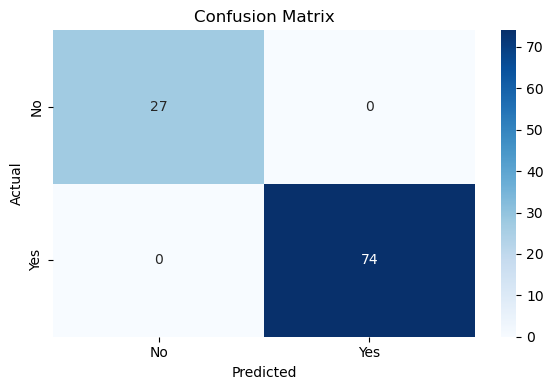

In [17]:

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_curve,auc
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

fetures = ['user_id','subject','study_time','duration','preferred_time']
X = df[fetures].copy()#fetures
y = df['reminder_response']#target

le = LabelEncoder()
categorical_cols = ['subject','preferred_time','study_time']
encoder={}

for col in categorical_cols:
    le = LabelEncoder()
    le.fit(df[col])
    df[col] = le.transform(df[col])
    encoder[col] = le

#print('Data_type_Encoding')
#print(df.head()

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


model =RandomForestClassifier(n_estimators = 100,random_state =42)
model.fit(X_train_scaled,y_train)


user_id = 1
user_data = df[df["user_id"] == user_id]
last_7 = user_data.tail(7)

avg_duration = last_7["duration"].mean()
study_time = last_7["study_time"].mode()[0]
preferred_time = last_7["preferred_time"].mode()[0]
subject = last_7["subject"].mode()[0]

new_input = pd.DataFrame([{
    "user_id": user_id,
    "subject": subject,
    "study_time": study_time,
    "duration": avg_duration,
    "preferred_time": preferred_time
}])

# encoding
for col in categorical_cols:
    new_input[col] = encoder[col].transform(new_input[col])

# scaling
new_input_scaled = scaler.transform(new_input)

# prediction
prediction = model.predict(new_input_scaled)[0]

y_pred = model.predict(X_test_scaled)

#print(prediction)

pickle.dump(model,open("model.pkl","wb"))
pickle.dump(scaler,open("scaler.pkl","wb"))

print("classification_report",)
print(classification_report(y_test,y_pred))

conf_matrix = confusion_matrix(y_test,y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix,annot=True, fmt="d", cmap="Blues",
            xticklabels=["No","Yes"],yticklabels=["No","Yes"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

